In [1]:


import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/yaminh/bank-marketing-campaign-dataset/dataset.csv


## Data Importing

In [2]:
# reading a csv file
data = pd.read_csv("/kaggle/input/datasets/yaminh/bank-marketing-campaign-dataset/dataset.csv")


In [3]:
# knowing structure of data
data.head()

,occupation,age,education_level,marital_status,communication_channel,call_month,call_day,call_duration,call_frequency,previous_campaign_outcome,conversion_status
0,administrative_staff,28,high_school,married,unidentified,September,9,1,1,successful,not_converted
1,administrative_staff,58,unidentified,married,unidentified,June,5,307,2,unidentified,not_converted
2,jobless,40,high_school,divorced,mobile,February,4,113,1,unidentified,not_converted
3,retired_worker,63,high_school,married,mobile,April,7,72,5,unidentified,not_converted
4,business_owner,43,college,married,landline,July,29,184,4,unidentified,not_converted


In [4]:
data.shape

(45211, 11)

In [5]:
# overview of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   occupation                 45211 non-null  object
 1   age                        45211 non-null  int64 
 2   education_level            45211 non-null  object
 3   marital_status             45211 non-null  object
 4   communication_channel      45211 non-null  object
 5   call_month                 45211 non-null  object
 6   call_day                   45211 non-null  int64 
 7   call_duration              45211 non-null  int64 
 8   call_frequency             45211 non-null  int64 
 9   previous_campaign_outcome  45211 non-null  object
 10  conversion_status          45211 non-null  object
dtypes: int64(4), object(7)
memory usage: 3.8+ MB


## Data Cleaning

In [6]:
# checking for null values
data.isna().sum()


occupation                   0
age                          0
education_level              0
marital_status               0
communication_channel        0
call_month                   0
call_day                     0
call_duration                0
call_frequency               0
previous_campaign_outcome    0
conversion_status            0
dtype: int64

In [7]:
# checking for duplicates records
data.duplicated().sum()

np.int64(6)

In [8]:
# dropping duplicates records
data.drop_duplicates(inplace=True)

In [9]:
data.shape

(45205, 11)

In [10]:
# finding unqiues values per column
for col in data.columns:
    print(col)
    print(data[col].unique())
    print()

occupation
['administrative_staff' 'jobless' 'retired_worker' 'business_owner'
 'manual_worker' 'student' 'technical_specialist' 'executive'
 'service_worker' 'independent_worker' 'unidentified' 'domestic_worker']

age
[28 58 40 63 43 39 42 68 22 53 55 59 48 46 36 71 52 50 34 37 51 25 33 32
 45 66 41 60 31 35 67 30 24 49 47 27 56 38 29 54 44 57 21 61 26 23 64 77
 70 62 73 74 75 69 18 72 78 81 95 82 89 20 80 79 65 76 19 86 93 84 83 85
 87 92 90 94 88]

education_level
['high_school' 'unidentified' 'college' 'elementary_school']

marital_status
['married' 'divorced' 'single']

communication_channel
['unidentified' 'mobile' 'landline']

call_month
['September' 'June' 'February' 'April' 'July' 'August' 'November' 'May'
 'January' 'October' 'March' 'December']

call_day
[ 9  5  4  7 29  6 10 30 13 16 25 12 20  8 19 27 18 28 14 15 11 26 31 21
 22 23 17  2  3 24  1]

call_duration
[   1  307  113 ... 1687 2621 1372]

call_frequency
[ 1  2  5  4  7  3  6 17 13 19 11 14  9 15  8 23 12 33 39 18 

## Data Transformation 

In [11]:
data['age_group'] = pd.cut(data['age'],
                           bins=[18,30,45,60,100],
                           labels=['18-30','30-45','45-60','60+'])


In [12]:
data['call_duration_group'] = pd.cut(
    data['call_duration'],
    bins=[0,60,300,1000,3000],
    labels=['very_short','short','medium','long']
)


In [13]:
data['call_intensity'] = data['call_frequency'].apply(
    lambda x: 'low' if x<=3 else 'medium' if x<=10 else 'high' if x<=30 else 'very_high'
)


In [14]:
month_to_quarter = {
    'January':'Q1','February':'Q1','March':'Q1',
    'April':'Q2','May':'Q2','June':'Q2',
    'July':'Q3','August':'Q3','September':'Q3',
    'October':'Q4','November':'Q4','December':'Q4'
}

data['quarter'] = data['call_month'].map(month_to_quarter)


## Analysis

### 1. Customer Demographic Analysis

Text(0, 0.5, 'frequency')

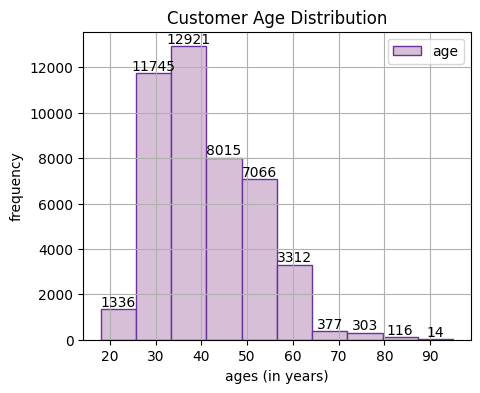

In [15]:
ax = data['age'].hist(legend=True, figsize = (5, 4), color='thistle', edgecolor="rebeccapurple")

ax.bar_label(ax.containers[0])

plt.title("Customer Age Distribution")
plt.xlabel("ages (in years)")
plt.ylabel("frequency")


The 30–40 bracket is our "Goldmine" or best covering age group with nearly 13k customers.

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'manual_worker'),
  Text(1, 0, 'executive'),
  Text(2, 0, 'technical_specialist'),
  Text(3, 0, 'administrative_staff'),
  Text(4, 0, 'service_worker'),
  Text(5, 0, 'retired_worker'),
  Text(6, 0, 'independent_worker'),
  Text(7, 0, 'business_owner'),
  Text(8, 0, 'jobless'),
  Text(9, 0, 'domestic_worker'),
  Text(10, 0, 'student'),
  Text(11, 0, 'unidentified')])

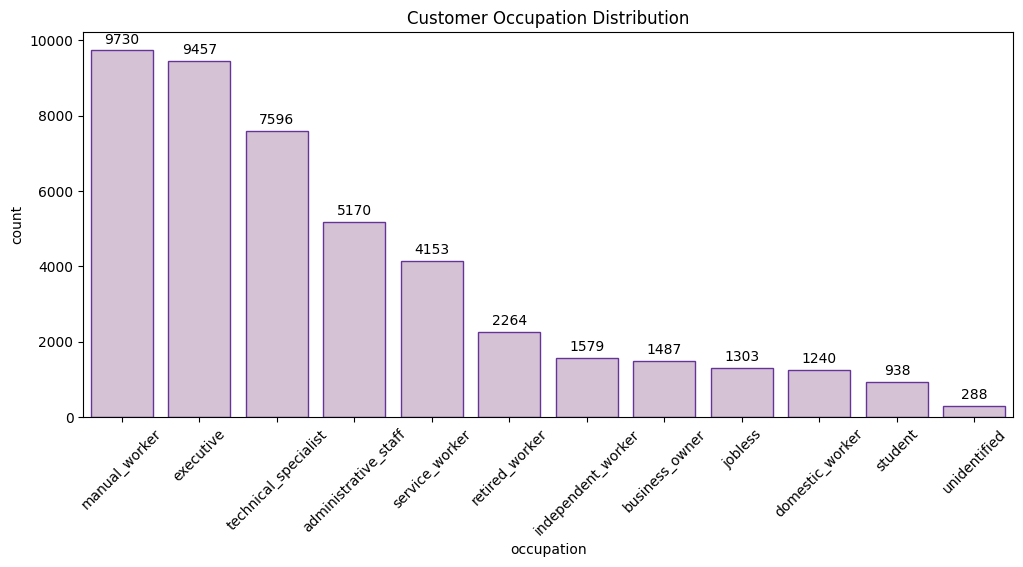

In [16]:
occupation_results = data['occupation'].value_counts().reset_index()
plt.figure(figsize=(12, 5))
ax = sns.barplot(x=occupation_results['occupation'], y=occupation_results['count'], color="thistle", edgecolor="rebeccapurple" )

ax.bar_label(ax.containers[0], padding=3)

plt.title("Customer Occupation Distribution")
plt.xticks(rotation=45)

Manual workers and Executives dominate, making up almost 20k of your base.

(array([0, 1, 2, 3]),
 [Text(0, 0, 'high_school'),
  Text(1, 0, 'college'),
  Text(2, 0, 'elementary_school'),
  Text(3, 0, 'unidentified')])

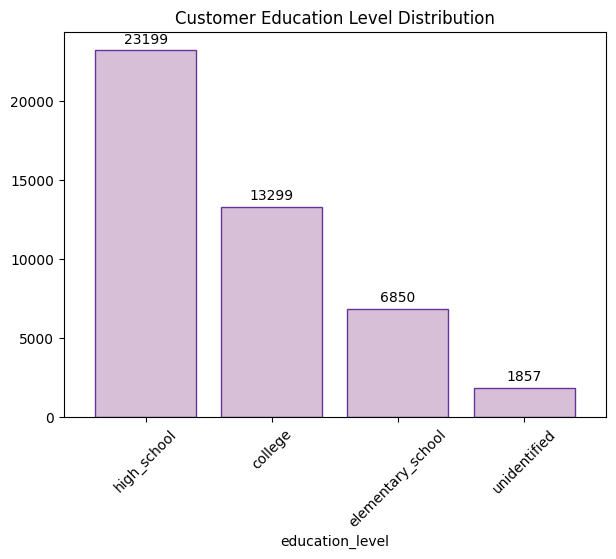

In [17]:

ax = data['education_level'].value_counts().plot(
    kind='bar', 
    color="thistle", 
    edgecolor="rebeccapurple", 
    width=0.8,
    figsize=(7, 5)
)

# ax.containers[0] automatically finds the height of your bars
ax.bar_label(ax.containers[0], padding=3)

plt.title("Customer Education Level Distribution")

plt.xticks(rotation=45)

Over 23k customers (the vast majority) stopped at the High School level.

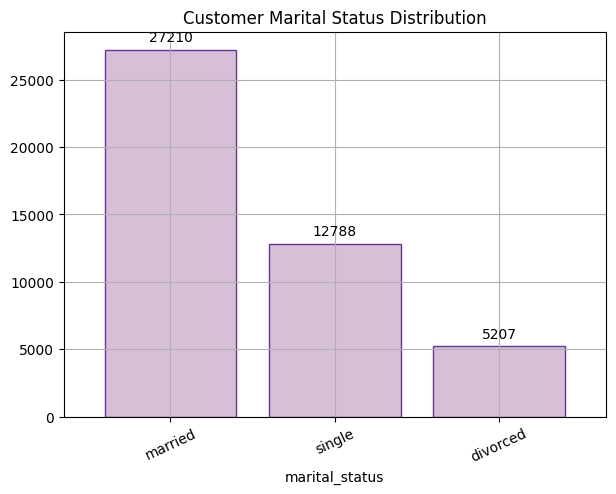

In [18]:
ax = data['marital_status'].value_counts().plot(
    kind='bar',
    color="thistle", 
    edgecolor="rebeccapurple", 
    width=0.8,
    figsize=(7, 5)

)

ax.bar_label(ax.containers[0], padding=4)

plt.title("")
plt.xticks(rotation=25)

plt.title("Customer Marital Status Distribution")

plt.grid()

Married individuals outnumber singles 2 to 1.

`Final Customers Demographic Insight:`

***Our core customer is a married, high-school-educated professional aged 30–40—this single segment represents over 50% of our entire reach.***

### 2. Campaign Interaction Analysis


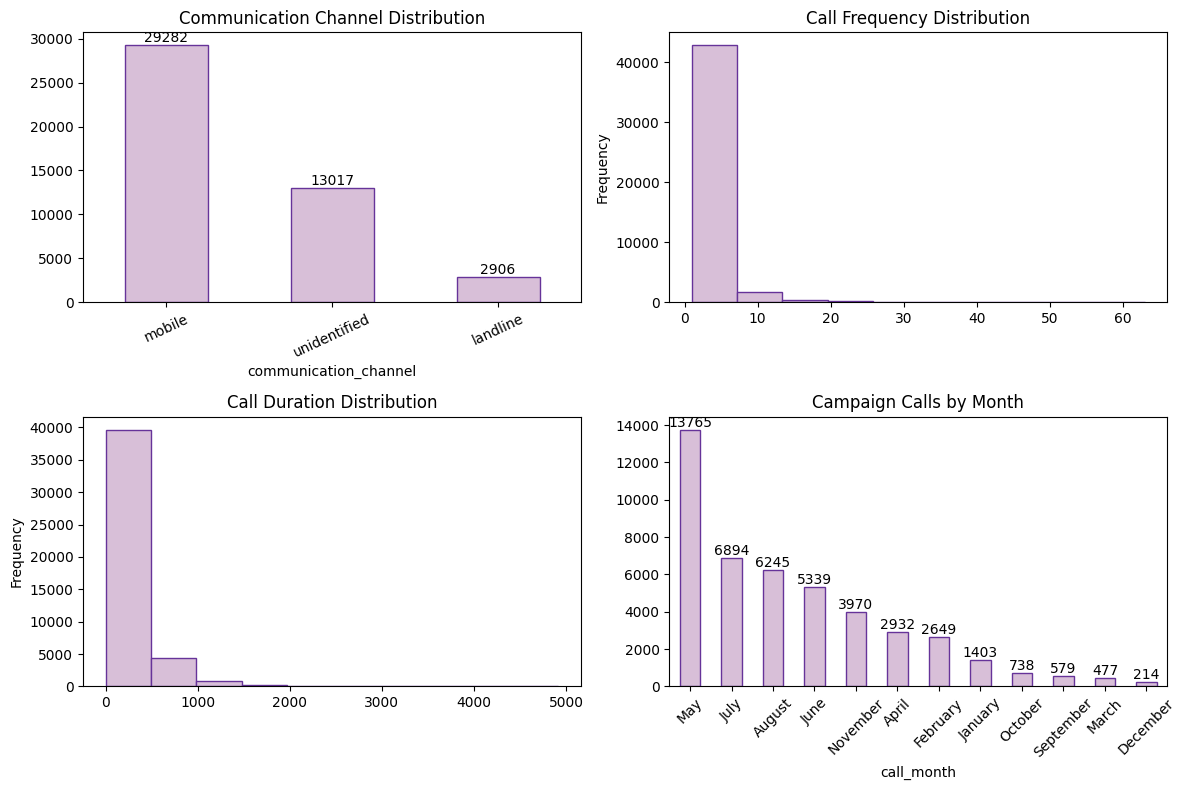

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,2, figsize=(12,8))

# Communication channel
bars1 = data['communication_channel'].value_counts().plot(
    kind='bar', ax=ax[0,0], color='thistle', edgecolor='rebeccapurple'
)
ax[0,0].set_title("Communication Channel Distribution")
ax[0,0].tick_params(axis='x', rotation=25)
ax[0,0].bar_label(ax[0,0].containers[0])

# Call frequency
data['call_frequency'].plot(
    kind='hist', ax=ax[0,1], color='thistle', edgecolor='rebeccapurple'
)
ax[0,1].set_title("Call Frequency Distribution")

# Call duration
data['call_duration'].plot(
    kind='hist', ax=ax[1,0], color='thistle', edgecolor='rebeccapurple'
)
ax[1,0].set_title("Call Duration Distribution")

# Call month
bars2 = data['call_month'].value_counts().plot(
    kind='bar', ax=ax[1,1], color='thistle', edgecolor='rebeccapurple'
)
ax[1,1].set_title("Campaign Calls by Month")
ax[1,1].tick_params(axis='x', rotation=45)
ax[1,1].bar_label(ax[1,1].containers[0])

plt.tight_layout()
plt.show()

65% of your reach is through mobile; however, the 13k unidentified channels represent a massive data-hygiene gap that could be hiding untapped ROI.

Most customers engage in short bursts (Call Duration); calls exceeding 500 seconds are outliers. Focusing on a high-impact "first 5 minutes" is the key to conversion.

May shows a massive volume surge (13.7k calls)—double the volume of July

Over 40,000 customers only need 1-5 calls. After 10 calls, the "Law of Diminishing Returns" hits hard—stop chasing high-frequency leads and reallocate that time to new prospects


`Final Campaign Interaction Insights`:

Stop over-calling dead leads and fix our mobile data gaps to turn May's 'busy work' into March's 'bankable results'.

### 3. Conversion Behavior Analysis


In [20]:
data['conversion_flag'] = (data['conversion_status'] == 'converted').astype(int)

/tmp/ipykernel_18/1437732117.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(col)['conversion_flag'].mean().plot(


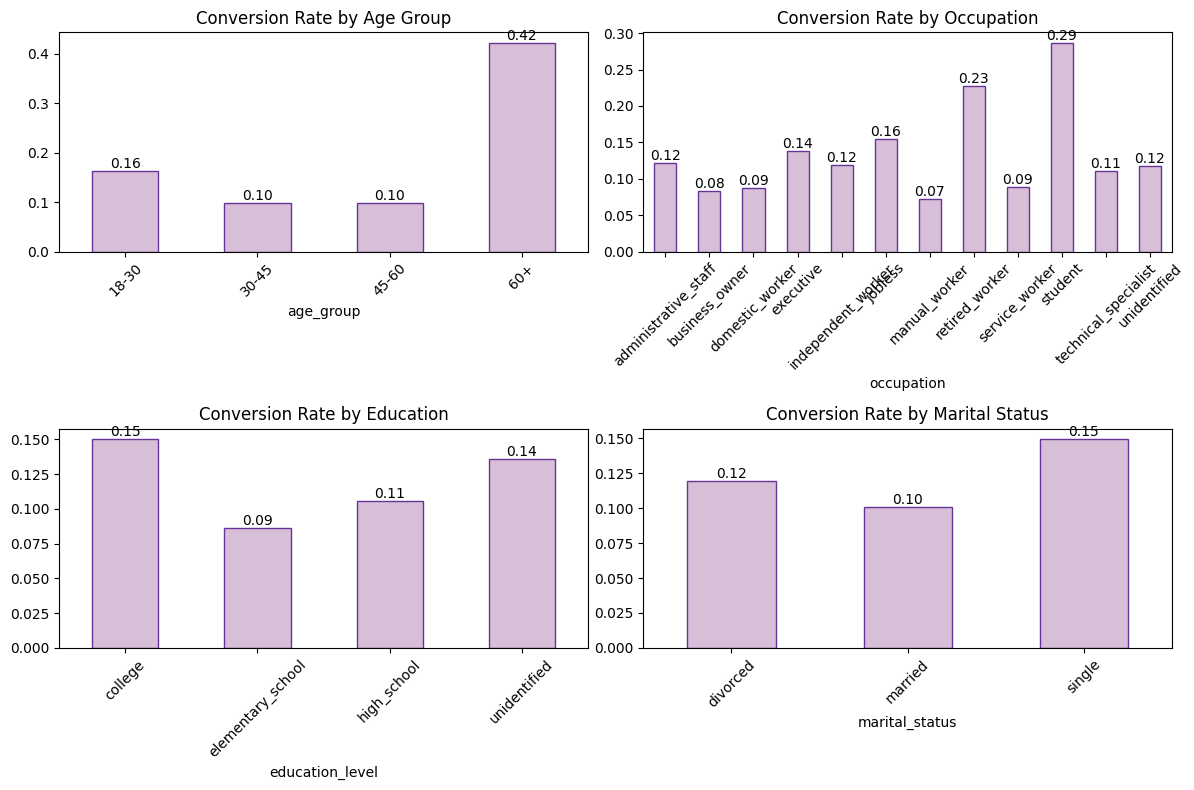

In [21]:
fig, ax = plt.subplots(2,2, figsize=(12,8))

plots = [
    ('age_group', ax[0,0], "Conversion Rate by Age Group"),
    ('occupation', ax[0,1], "Conversion Rate by Occupation"),
    ('education_level', ax[1,0], "Conversion Rate by Education"),
    ('marital_status', ax[1,1], "Conversion Rate by Marital Status")
]

for col, axis, title in plots:
    data.groupby(col)['conversion_flag'].mean().plot(
        kind='bar',
        ax=axis,
        color='thistle',
        edgecolor='rebeccapurple'
    )
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=45)
    axis.bar_label(axis.containers[0], fmt='%.2f')

plt.tight_layout()
plt.show()

Students and the 60+ age group are your "super-converters," outperforming the core 30–60 working class by 4x.

`Final Consumer Behaviour Insight`:

***Hence, Pivoting marketing spend from "Married/Working" segments to Students and Retirees to instantly maximize ROI with less effort.***

### 4. Previous Campaign Impact


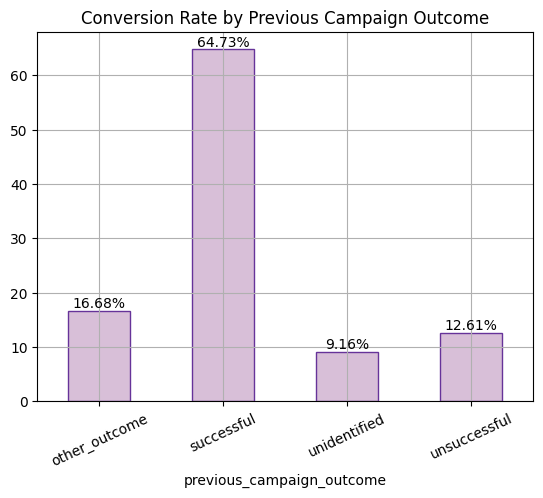

In [22]:
ax = (data.groupby('previous_campaign_outcome')['conversion_flag'].mean()*100).plot(
    kind='bar',
    color='thistle',
    edgecolor='rebeccapurple'
)

ax.bar_label(ax.containers[0], fmt="%.2f%%")
plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xticks(rotation=25)
plt.grid()

plt.show()

Success breeds success: Past winners convert at 64.73%, which is over 5x higher than those who failed before.

In [23]:
# data

### 5. Conversion Rates by Months and Quarters

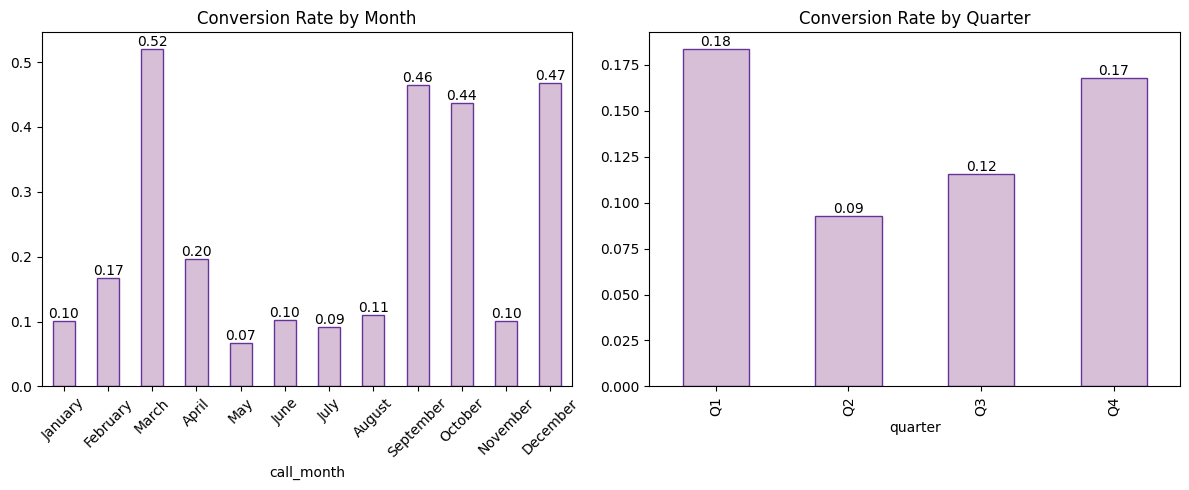

In [24]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

# Month order
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

# Month vs conversion
month_conv = data.groupby('call_month')['conversion_flag'].mean().reindex(month_order)

month_conv.plot(
    kind='bar',
    ax=ax[0],
    color='thistle',
    edgecolor='rebeccapurple'
)

ax[0].set_title("Conversion Rate by Month")
ax[0].tick_params(axis='x', rotation=45)
ax[0].bar_label(ax[0].containers[0], fmt="%.2f")

# Quarter vs conversion
quarter_conv = data.groupby('quarter')['conversion_flag'].mean()

quarter_conv.plot(
    kind='bar',
    ax=ax[1],
    color='thistle',
    edgecolor='rebeccapurple'
)

ax[1].set_title("Conversion Rate by Quarter")
ax[1].bar_label(ax[1].containers[0], fmt="%.2f")

plt.tight_layout()
plt.show()

March is our powerhouse at 52% conversion—nearly 5x higher than our summer periods, also creating a massive performance gap compared to the 7% low in May.
We hit a 47% high in December; the goal is to bridge the May-July gap (0.07-0.10) to match that momentum


`Final Period Insight:`

***Study the March "success formula" and apply those exact tactics to May to prevent the mid-year revenue slump.***

## Conclusion

target the 60+ and student segments via mobile, cap call frequency at 5, and replicate March’s 52% conversion strategy to eliminate the mid-year slump.